# 05 Causal Analysis
**Project:** Quantifying Politeness in Online Educational Forums  
**Author:** Karan Raman  
**Purpose:** This notebook estimates causal effects of contextual factors on politeness using:
1. **Back-door criterion** (Maathuis & Colombo, 2015) identify valid adjustment sets
2. **X-learner** (Künzel et al., 2019) estimate heterogeneous treatment effects

**Treatments analysed:**
- Anonymity (anonymous vs non-anonymous)
- Post type (question vs non-question)
- Urgency level (high vs low)
- Confusion level (high vs low)

**Run After:** 04_analysis.ipynb
**Input:** data/processed/posts_analysis.parquet
**Output:** data/outputs/backdoor_results.csv

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu
from dowhy import CausalModel
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', font_scale=1.1)
mpl.rcParams.update({
    'figure.figsize'    : (10, 6),
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.alpha'        : 0.3,
})

BLUE, RED, GREEN, GREY = '#2166AC', '#D6604D', '#1A9641', '#878787'
sns.set_palette([BLUE, RED, GREEN, GREY, '#F4A582'])

DATA_PROCESSED = Path('../data/processed')
DATA_OUT       = Path('../data/outputs')
DATA_OUT.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.



## 1. Load data & prepare features

In [2]:
# load data and prepare features for causal modelling

df = pd.read_parquet(DATA_PROCESSED / 'posts_analysis.parquet')

numeric_cols = ['politeness_score', 'sentiment', 'confusion', 'urgency',
                'anonymous', 'is_question', 'is_answer', 'is_opinion',
                'up_count', 'reads', 'word_count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# keep only valid disciplines and encode for ML
df = df[df['course_type'].isin(['Education', 'Humanities', 'Medicine'])].copy()
le = LabelEncoder()
df['course_type_enc'] = le.fit_transform(df['course_type'].astype(str))

# binarise urgency and confusion at median
df['high_urgency']   = (df['urgency']   >= df['urgency'].median()).astype(int)
df['high_confusion'] = (df['confusion'] >= df['confusion'].median()).astype(int)

key_cols = ['politeness_score', 'sentiment', 'confusion', 'urgency',
            'anonymous', 'is_question', 'word_count', 'course_type_enc']
df_model = df.dropna(subset=key_cols).copy()
print(f'Loaded {len(df):,} posts, model dataset {len(df_model):,} posts')

Loaded 28,264 posts, model dataset 28,264 posts


In [3]:
# create response timing treatment variable

df_model['created_at'] = pd.to_datetime(df_model['created_at'], errors='coerce', utc=True)

df_timing = df_model[df_model['response_time_hours'] > 0].copy()
df_timing['is_late_response'] = (df_timing['response_time_hours'] >= 24).astype(int)

print(f'Posts with valid response time : {len(df_timing):,}')
print(f'Early (< 24 hrs)               : {(df_timing["is_late_response"]==0).sum():,}')
print(f'Late  (>= 24 hrs)              : {(df_timing["is_late_response"]==1).sum():,}')
print(f'Treatment rate                 : {df_timing["is_late_response"].mean()*100:.1f}%')

Posts with valid response time : 8,168
Early (< 24 hrs)               : 3,950
Late  (>= 24 hrs)              : 4,218
Treatment rate                 : 51.6%


## 2. Back-door criterion
Estimating average treatment effects for all five treatments using the generalised back-door criterion with placebo refutation and stability checks.

**Causal DAG back-door criterion**

We build a Directed Acyclic Graph (DAG) encoding our causal assumptions. The back-door criterion identifies which variables to condition on (adjust for) to block spurious paths and isolate the true causal effect.

DAG structure:
- course_type -> urgency, confusion, post_type, politeness
- urgency -> politeness, anonymous
- confusion -> politeness, is_question
- sentiment -> politeness
- word_count -> politeness
- Treatment -> politeness (effect we want to estimate)

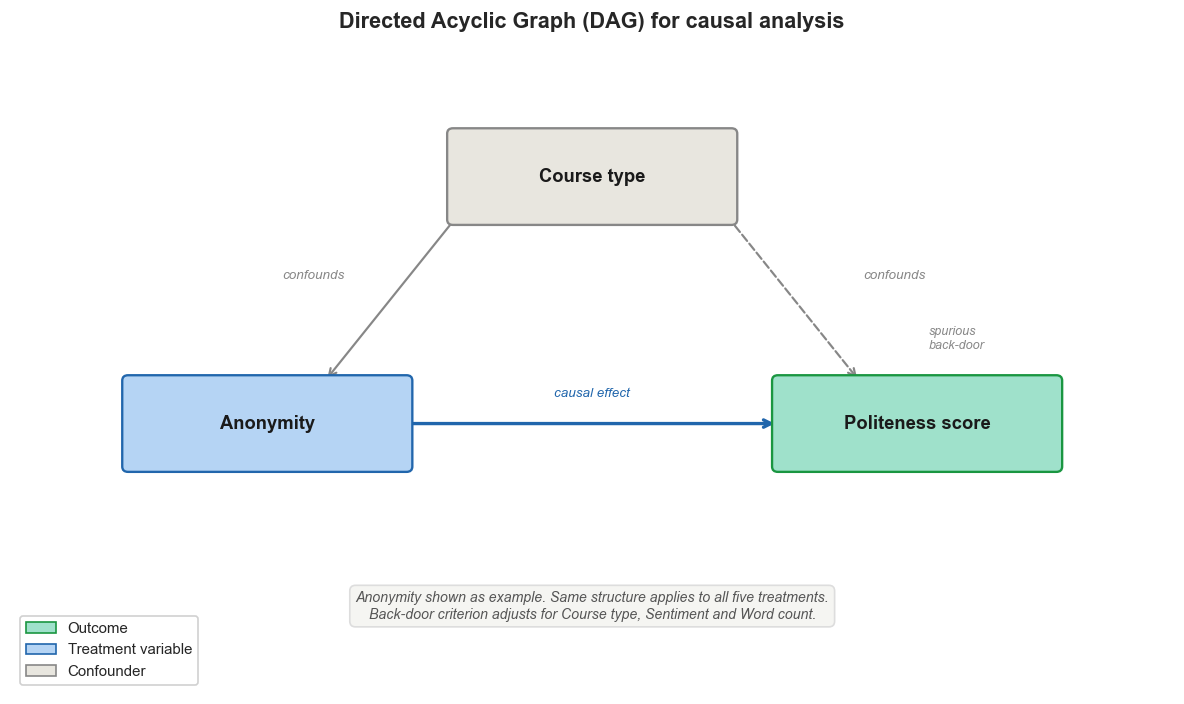

In [4]:
# DAG visualisation for causal analysis
from matplotlib.patches import FancyBboxPatch

C_CONF  = '#E8E6DF'; E_CONF  = GREY
C_TREAT = '#B5D4F4'; E_TREAT = BLUE
C_OUT   = '#9FE1CB'; E_OUT   = GREEN

def draw_box(ax, x, y, w, h, label, fc, ec, fs=11):
    ax.add_patch(FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.05',
        facecolor=fc, edgecolor=ec,
        linewidth=1.4, zorder=3
    ))
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='#1a1a1a', zorder=4)

def arrow(ax, x1, y1, x2, y2, color, lw=1.5, dashed=False):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='->', color=color, lw=lw,
            linestyle='dashed' if dashed else 'solid',
            connectionstyle='arc3,rad=0.0'
        ), zorder=2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

draw_box(ax, 5.0, 4.8, 2.4, 0.8, 'Course type',     C_CONF,  E_CONF)
draw_box(ax, 2.2, 2.5, 2.4, 0.8, 'Anonymity',        C_TREAT, E_TREAT)
draw_box(ax, 7.8, 2.5, 2.4, 0.8, 'Politeness score', C_OUT,   E_OUT)

arrow(ax, 3.85, 4.45, 2.7,  2.9, E_CONF,  lw=1.3)
arrow(ax, 6.15, 4.45, 7.3,  2.9, E_CONF,  lw=1.3, dashed=True)
arrow(ax, 3.4,  2.5,  6.6,  2.5, E_TREAT, lw=2.0)

ax.text(2.6, 3.85, 'confounds',            fontsize=8, color=E_CONF,  style='italic', ha='center')
ax.text(7.6, 3.85, 'confounds',            fontsize=8, color=E_CONF,  style='italic', ha='center')
ax.text(5.0, 2.75, 'causal effect',        fontsize=8, color=E_TREAT, style='italic', ha='center')
ax.text(7.9, 3.2,  'spurious\nback-door',  fontsize=7.5, color=E_CONF, style='italic', ha='left')

ax.legend(handles=[
    mpatches.Patch(facecolor=C_OUT,   edgecolor=E_OUT,   label='Outcome'),
    mpatches.Patch(facecolor=C_TREAT, edgecolor=E_TREAT, label='Treatment variable'),
    mpatches.Patch(facecolor=C_CONF,  edgecolor=E_CONF,  label='Confounder'),
], loc='lower left', fontsize=9, framealpha=0.9, edgecolor='#cccccc')

ax.text(5.0, 0.8,
        'Anonymity shown as example. Same structure applies to all five treatments.\n'
        'Back-door criterion adjusts for Course type, Sentiment and Word count.',
        ha='center', va='center', fontsize=8.5, color='#555555', style='italic',
        bbox=dict(facecolor='#f5f5f2', edgecolor='#dddddd', boxstyle='round,pad=0.4'))

ax.set_title('Directed Acyclic Graph (DAG) for causal analysis',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_dag_causal.png', facecolor='white')
plt.show()

In [5]:
# back-door causal estimation function using DoWhy
import logging
logging.getLogger('dowhy').setLevel(logging.ERROR)

def run_backdoor_analysis(df, treatment, outcome, common_causes, treatment_label):
    print(f'\n{treatment_label}')

    model = CausalModel(data=df, treatment=treatment,
                        outcome=outcome, common_causes=common_causes)

    identified = model.identify_effect(proceed_when_unidentifiable=True)
    estimate   = model.estimate_effect(identified,
                                       method_name='backdoor.linear_regression',
                                       control_value=0, treatment_value=1)

    refute = model.refute_estimate(identified, estimate,
                                   method_name='placebo_treatment_refuter',
                                   placebo_type='permute', num_simulations=100)

    p_val = refute.refutation_result['p_value']
    print(f'  ATE: {estimate.value:.4f}  |  Placebo p: {p_val:.4f}')

    return estimate.value, p_val

### Back-door analysis: Anonymity -> Politeness

In [6]:
# back-door analysis for anonymity
base_confounders = ['course_type_enc', 'sentiment', 'word_count']
anon_confounders = base_confounders + ['urgency', 'confusion']

ate_anon, p_anon = run_backdoor_analysis(
    df=df_model,
    treatment='anonymous',
    outcome='politeness_score',
    common_causes=anon_confounders,
    treatment_label='Anonymity'
)


Anonymity
  ATE: 0.1812  |  Placebo p: 0.8000


### Back-door analysis: Question posts -> Politeness

In [7]:
# back-door analysis for question posts
question_confounders = base_confounders + ['confusion', 'urgency']

ate_q, p_q = run_backdoor_analysis(
    df=df_model,
    treatment='is_question',
    outcome='politeness_score',
    common_causes=question_confounders,
    treatment_label='Question post'
)


Question post
  ATE: -0.2206  |  Placebo p: 0.8400


### Back-door analysis: High urgency -> Politeness

In [8]:
# back-door analysis for high urgency
urgency_confounders = base_confounders + ['confusion', 'is_question']

ate_urg, p_urg = run_backdoor_analysis(
    df=df_model,
    treatment='high_urgency',
    outcome='politeness_score',
    common_causes=urgency_confounders,
    treatment_label='High urgency'
)


High urgency
  ATE: 0.0705  |  Placebo p: 0.9000


### Back-door analysis: High confusion -> Politeness

In [9]:
# back-door analysis for high confusion
confusion_confounders = base_confounders + ['urgency', 'is_question']

ate_conf, p_conf = run_backdoor_analysis(
    df=df_model,
    treatment='high_confusion',
    outcome='politeness_score',
    common_causes=confusion_confounders,
    treatment_label='High confusion'
)


High confusion
  ATE: 0.1032  |  Placebo p: 0.9800


### Back-door analysis: Response Timing -> Politeness

In [10]:
# back-door analysis for response timing
timing_confounders = base_confounders + ['confusion', 'is_question', 'urgency']

ate_timing, p_timing = run_backdoor_analysis(
    df=df_timing.dropna(subset=timing_confounders + ['is_late_response', 'politeness_score']),
    treatment='is_late_response',
    outcome='politeness_score',
    common_causes=timing_confounders,
    treatment_label='Late response timing'
)


Late response timing
  ATE: 0.1121  |  Placebo p: 0.8800


In [11]:
# summarise back-door results
backdoor_results = pd.DataFrame({
    'Treatment'    : ['Anonymity', 'Question post', 'High urgency', 'High confusion', 'Late response timing'],
    'ATE'          : [ate_anon, ate_q, ate_urg, ate_conf, ate_timing],
    'Refutation p' : [p_anon,   p_q,   p_urg,   p_conf,   p_timing],
})
backdoor_results['Significant'] = backdoor_results['Refutation p'] < 0.05
print(backdoor_results.round(4).to_string(index=False))
backdoor_results.to_csv(DATA_OUT / 'backdoor_results.csv', index=False)

           Treatment     ATE  Refutation p  Significant
           Anonymity  0.1812          0.80        False
       Question post -0.2206          0.84        False
        High urgency  0.0705          0.90        False
      High confusion  0.1032          0.98        False
Late response timing  0.1121          0.88        False


### Stability checks
Rechecking back-door analysis on five random 80% data subsets to confirm ATE estimates are consistent across different samples.

In [12]:
# re-run back-door on 5x 80% random subsets
N_SUBSETS   = 5
SUBSET_FRAC = 0.8
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

timing_confounders = base_confounders + ['confusion', 'is_question', 'urgency']

treatments = [
    ('anonymous',        'Anonymity',            base_confounders + ['urgency', 'confusion'],    df_model),
    ('is_question',      'Question post',        base_confounders + ['confusion', 'urgency'],    df_model),
    ('high_urgency',     'High urgency',         base_confounders + ['confusion', 'is_question'],df_model),
    ('high_confusion',   'High confusion',       base_confounders + ['urgency', 'is_question'],  df_model),
    ('is_late_response', 'Late response timing', timing_confounders,                             df_timing),
]

robustness_results = []

for treatment_col, label, confounders, source_df in treatments:
    ates = []
    for i in range(N_SUBSETS):
        subset = source_df.sample(frac=SUBSET_FRAC, random_state=RANDOM_SEED + i)
        subset = subset.dropna(subset=confounders + [treatment_col, 'politeness_score'])
        try:
            model    = CausalModel(data=subset, treatment=treatment_col,
                                   outcome='politeness_score', common_causes=confounders)
            identified = model.identify_effect(proceed_when_unidentifiable=True)
            estimate   = model.estimate_effect(identified,
                                               method_name='backdoor.linear_regression',
                                               control_value=0, treatment_value=1)
            ates.append(estimate.value)
        except:
            ates.append(np.nan)

    mean_ate = np.nanmean(ates)
    std_ate  = np.nanstd(ates)
    robustness_results.append({'Treatment': label, 'Mean ATE': round(mean_ate, 4),
                                'Std ATE': round(std_ate, 4),
                                'Stable': 'Yes' if std_ate < 0.05 else 'No'})
    print(f'{label}: ATEs={[round(a,4) for a in ates]}, mean={mean_ate:.4f}, std={std_ate:.4f}')

robustness_df = pd.DataFrame(robustness_results)
print(f'\n{robustness_df.to_string(index=False)}')
robustness_df.to_csv(DATA_OUT / 'robustness_checks.csv', index=False)

Anonymity: ATEs=[np.float64(0.1863), np.float64(0.1873), np.float64(0.1802), np.float64(0.1887), np.float64(0.1261)], mean=0.1737, std=0.0240
Question post: ATEs=[np.float64(-0.2064), np.float64(-0.2193), np.float64(-0.2103), np.float64(-0.2288), np.float64(-0.225)], mean=-0.2179, std=0.0085
High urgency: ATEs=[np.float64(0.0803), np.float64(0.0836), np.float64(0.067), np.float64(0.0779), np.float64(0.0697)], mean=0.0757, std=0.0063
High confusion: ATEs=[np.float64(0.0935), np.float64(0.0896), np.float64(0.0992), np.float64(0.1106), np.float64(0.1097)], mean=0.1005, std=0.0084
Late response timing: ATEs=[np.float64(0.091), np.float64(0.1157), np.float64(0.1027), np.float64(0.1081), np.float64(0.0752)], mean=0.0985, std=0.0142

           Treatment  Mean ATE  Std ATE Stable
           Anonymity    0.1737   0.0240    Yes
       Question post   -0.2179   0.0085    Yes
        High urgency    0.0757   0.0063    Yes
      High confusion    0.1005   0.0084    Yes
Late response timing    0.09

## 4. X-learner
Estimating individual treatment effects for all five treatments using the X-learner algorithm to reveal heterogeneity across subgroups and disciplines.


The X-learner estimates how treatment effects vary across subgroups.  
Key question: does the effect of e.g. urgency on politeness differ by course type?

Reference: Künzel et al. (2019) 

In [13]:
# X-learner implementation following Kunzel et al. (2019)

def run_xlearner(df, treatment_col, outcome_col, feature_cols, treatment_label):
    print(f'\n{treatment_label}')

    X = df[feature_cols].values
    T = df[treatment_col].values.astype(int)
    Y = df[outcome_col].values

    X_t, Y_t = X[T == 1], Y[T == 1]
    X_c, Y_c = X[T == 0], Y[T == 0]

    # stage 1: outcome models
    m_t = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    m_c = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    m_t.fit(X_t, Y_t)
    m_c.fit(X_c, Y_c)

    # stage 2: pseudo ITEs
    ite_t = Y_t - m_c.predict(X_t)
    ite_c = m_t.predict(X_c) - Y_c

    # stage 3: ITE models
    tau_t = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    tau_c = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    tau_t.fit(X_t, ite_t)
    tau_c.fit(X_c, ite_c)

    # propensity weighting
    prop_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    prop_model.fit(X, T)
    propensity = np.clip(prop_model.predict_proba(X)[:, 1], 0.01, 0.99)

    ite = (1 - propensity) * tau_t.predict(X) + propensity * tau_c.predict(X)

    print(f'  Mean ITE : {ite.mean():.4f}')
    print(f'  Std ITE  : {ite.std():.4f}')

    return ite

In [14]:
# features used across all X-learner models
xlearner_features = ['course_type_enc', 'sentiment', 'confusion',
                     'urgency', 'word_count', 'is_question']

### X-learner: Anonymity

In [15]:
ite_anon = run_xlearner(df_model, 'anonymous', 'politeness_score',
                        xlearner_features, 'Anonymity')
df_model['ite_anonymity'] = ite_anon


Anonymity
  Mean ITE : 0.1123
  Std ITE  : 0.5136


### X-learner: High urgency

In [16]:
ite_urg = run_xlearner(df_model, 'high_urgency', 'politeness_score',
                       xlearner_features, 'High urgency')
df_model['ite_urgency'] = ite_urg


High urgency
  Mean ITE : 0.0874
  Std ITE  : 0.2268


### X-learner: Question post

In [17]:
ite_q = run_xlearner(df_model, 'is_question', 'politeness_score',
                     xlearner_features, 'Question post')
df_model['ite_question'] = ite_q


Question post
  Mean ITE : -0.2999
  Std ITE  : 0.2657


### X-learner: High confusion

In [18]:
ite_conf = run_xlearner(df_model, 'high_confusion', 'politeness_score',
                        xlearner_features, 'High confusion')
df_model['ite_confusion'] = ite_conf


High confusion
  Mean ITE : 0.0319
  Std ITE  : 0.2920


### X-learner: Late response timing

In [19]:
ite_timing = run_xlearner(
    df_timing.dropna(subset=xlearner_features + ['is_late_response', 'politeness_score']),
    'is_late_response', 'politeness_score', xlearner_features, 'Late response timing'
)
df_timing['ite_timing'] = ite_timing


Late response timing
  Mean ITE : 0.0745
  Std ITE  : 0.1619


In [20]:
# summarise x-learner results
xlearner_results = pd.DataFrame({
    'Treatment'  : ['Anonymity', 'Question post', 'High urgency', 'High confusion', 'Late response timing'],
    'Mean ITE'   : [ite_anon.mean(),   ite_q.mean(),   ite_urg.mean(),   ite_conf.mean(),   ite_timing.mean()],
    'Std ITE'    : [ite_anon.std(),    ite_q.std(),    ite_urg.std(),    ite_conf.std(),    ite_timing.std()],
    'Median ITE' : [np.median(ite_anon), np.median(ite_q), np.median(ite_urg), np.median(ite_conf), np.median(ite_timing)],
})
print(xlearner_results.round(4).to_string(index=False))
xlearner_results.to_csv(DATA_OUT / 'xlearner_results.csv', index=False)

           Treatment  Mean ITE  Std ITE  Median ITE
           Anonymity    0.1123   0.5136      0.1419
       Question post   -0.2999   0.2657     -0.2557
        High urgency    0.0874   0.2268      0.0433
      High confusion    0.0319   0.2920      0.0659
Late response timing    0.0745   0.1619      0.0791


## 4. Heterogeneous effects by course type
Key question: does the treatment effect vary across course disciplines?

In [21]:
# discipline-level mean ITEs for all five treatments
for ite_col, label, source in [
    ('ite_anonymity', 'Anonymity',      df_model),
    ('ite_urgency',   'High urgency',   df_model),
    ('ite_question',  'Question post',  df_model),
    ('ite_confusion', 'High confusion', df_model),
    ('ite_timing',    'Late response',  df_timing),
]:
    print(f'\n{label}:')
    print(source.groupby('course_type')[ite_col].mean().round(4).to_string())


Anonymity:
course_type
Education     0.1092
Humanities    0.0644
Medicine      0.1630

High urgency:
course_type
Education     0.0243
Humanities    0.0253
Medicine      0.2137

Question post:
course_type
Education    -0.3923
Humanities   -0.3099
Medicine     -0.1953

High confusion:
course_type
Education    -0.0186
Humanities    0.1360
Medicine     -0.0196

Late response:
course_type
Education     0.0673
Humanities    0.0975
Medicine      0.0584


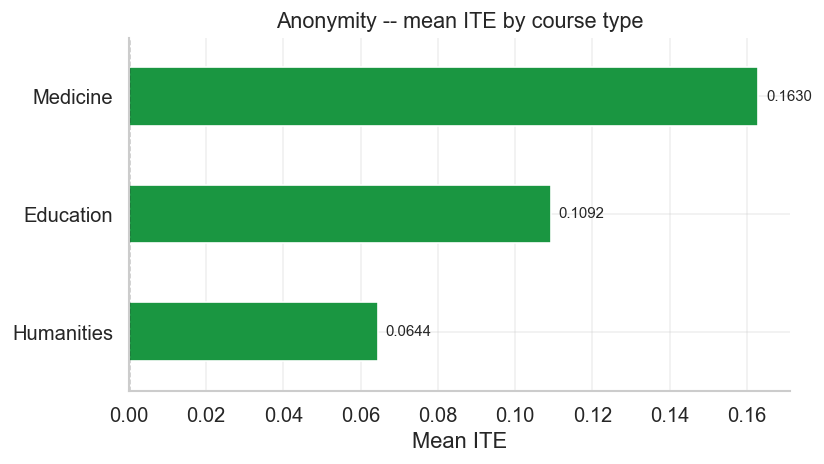

Saved fig_hte_anonymity.png


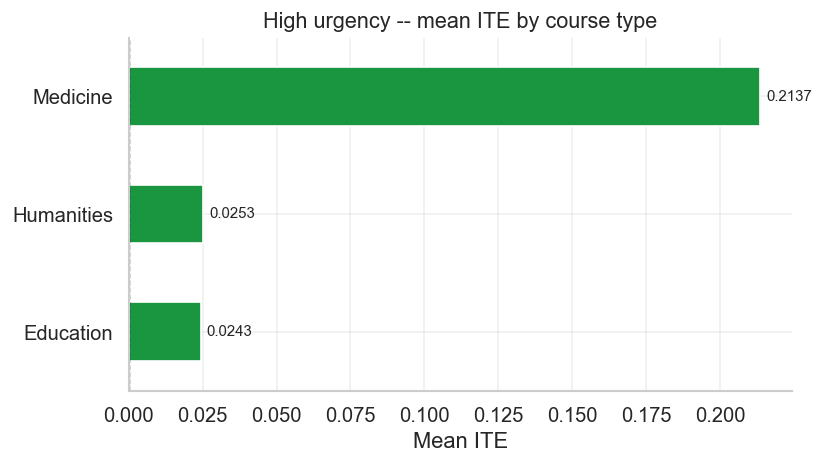

Saved fig_hte_urgency.png


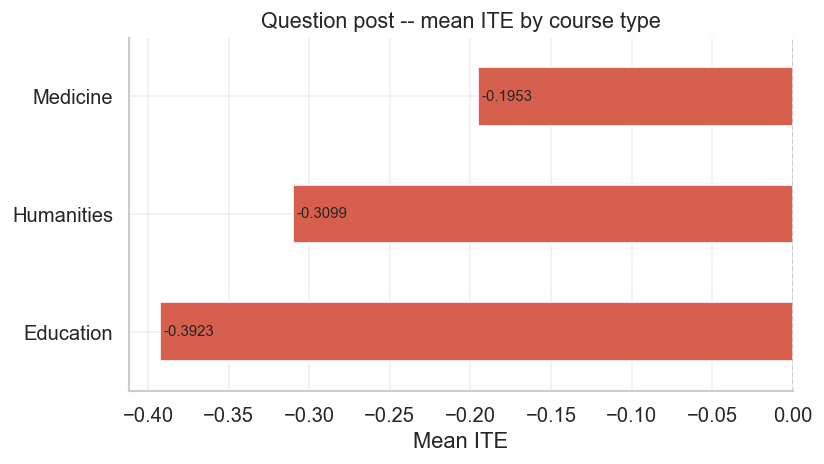

Saved fig_hte_question.png


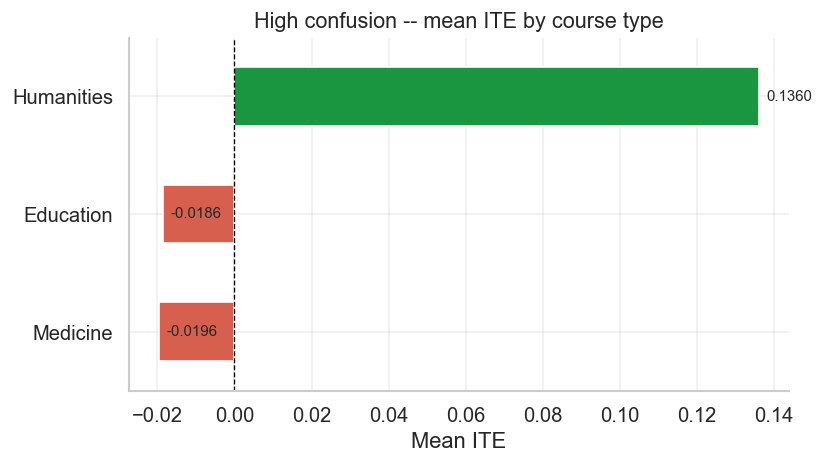

Saved fig_hte_confusion.png


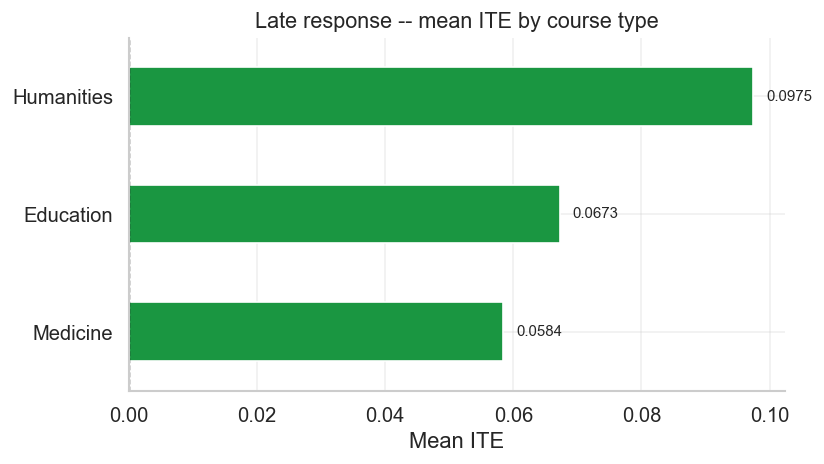

Saved fig_hte_timing.png


In [22]:
# ITE by course discipline
ite_cols = [
    ('ite_anonymity', 'Anonymity',      df_model),
    ('ite_urgency',   'High urgency',   df_model),
    ('ite_question',  'Question post',  df_model),
    ('ite_confusion', 'High confusion', df_model),
    ('ite_timing',    'Late response',  df_timing),
]

valid_disciplines = ['Education', 'Humanities', 'Medicine']

for ite_col, label, source_df in ite_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    filtered   = source_df[source_df['course_type'].astype(str).isin(valid_disciplines)]
    course_ite = filtered.groupby('course_type')[ite_col].mean().sort_values()
    colors_bar = [GREEN if v > 0 else RED for v in course_ite.values]
    course_ite.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{label} -- mean ITE by course type')
    ax.set_xlabel('Mean ITE')
    ax.set_ylabel('')

    for bar in ax.patches:
        ax.text(bar.get_width() + 0.002,
                bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.4f}',
                ha='left', va='center', fontsize=9)

    fname = f"fig_hte_{ite_col.replace('ite_', '')}.png"
    plt.tight_layout()
    plt.savefig(DATA_OUT / fname)
    plt.show()
    print(f'Saved {fname}')

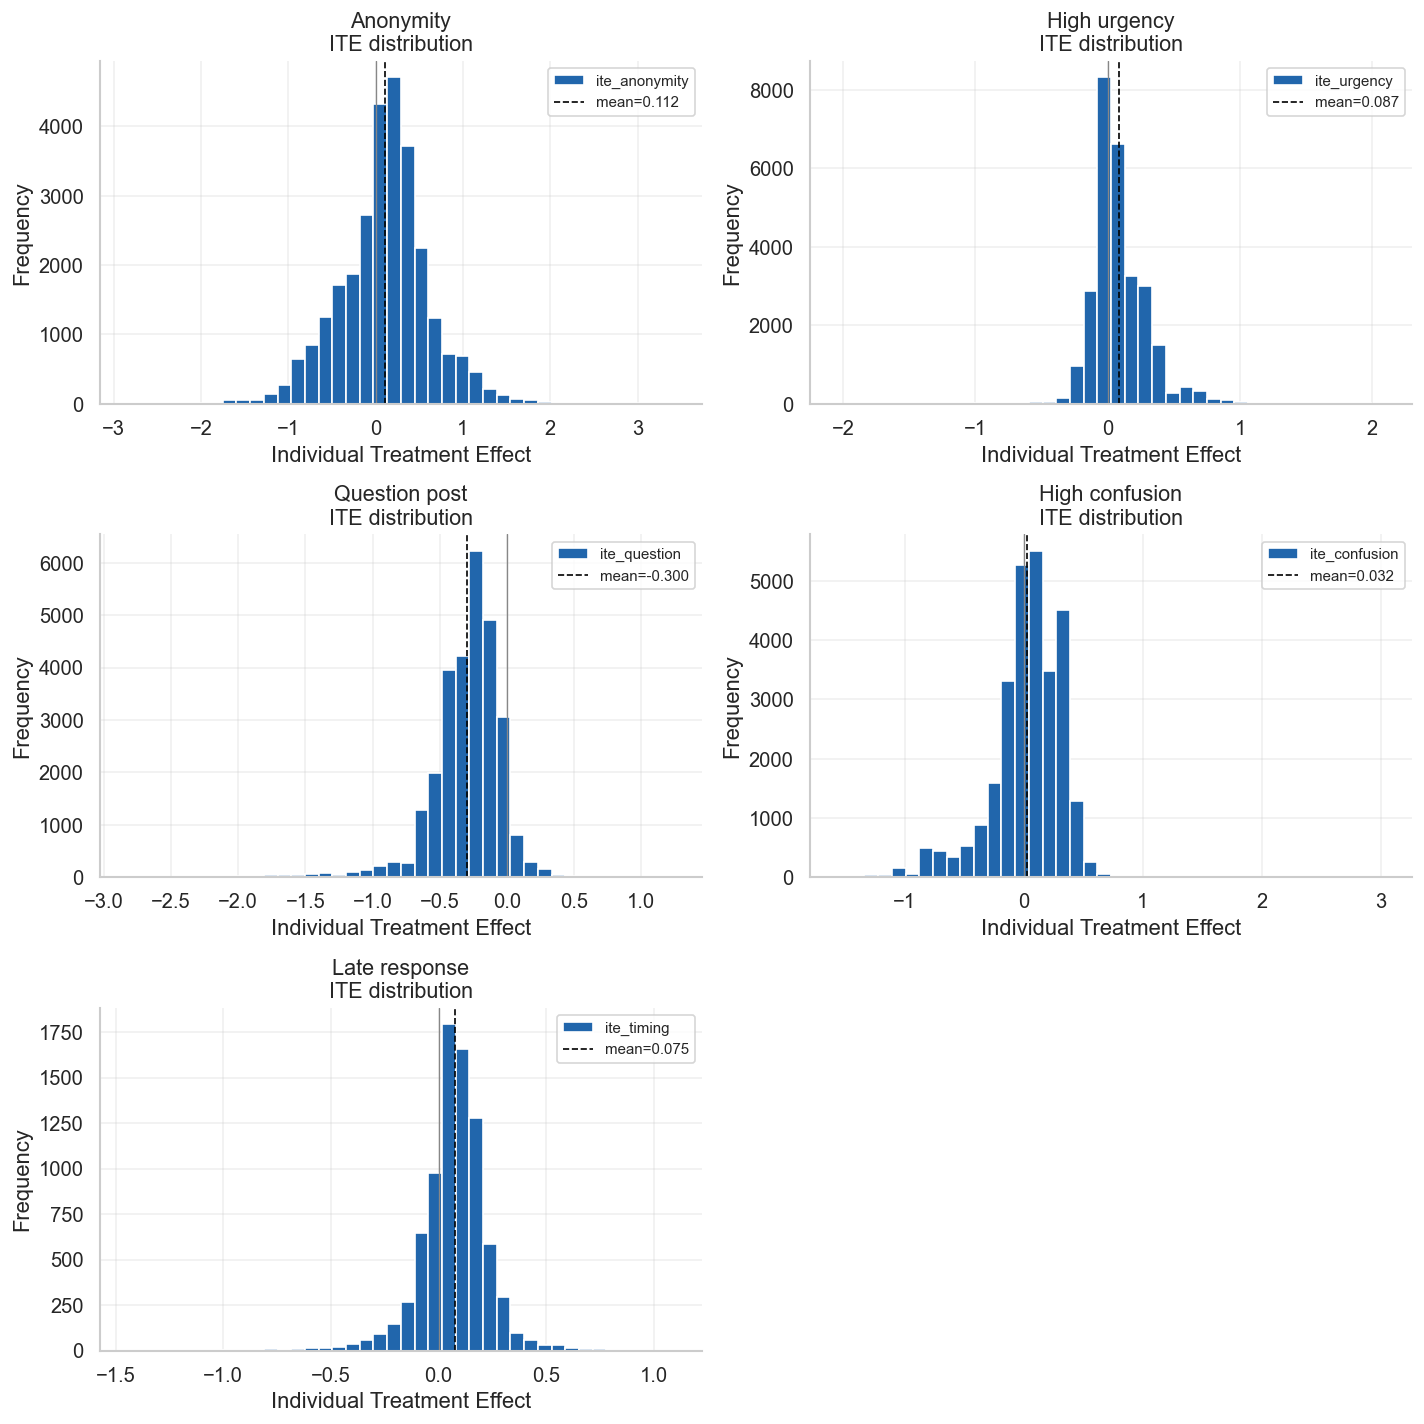

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, (ite_col, label, source_df) in enumerate(ite_cols):
    ax = axes[idx]
    source_df[ite_col].plot(kind='hist', bins=40, ax=ax, color=BLUE, edgecolor='white')
    ax.axvline(source_df[ite_col].mean(), color='black', linestyle='--',
               linewidth=1, label=f"mean={source_df[ite_col].mean():.3f}")
    ax.axvline(0, color=GREY, linestyle='-', linewidth=0.8)
    ax.set_title(f'{label}\nITE distribution')
    ax.set_xlabel('Individual Treatment Effect')
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_xlearner_ite_distributions.png')
plt.show()

## 5. Who is most affected? Subgroup analysis

In [24]:
# who is most affected by urgency treatment
df_model['urgency_effect_group'] = np.where(
    df_model['ite_urgency'] > df_model['ite_urgency'].median(),
    'High effect', 'Low effect'
)

profile_cols = ['sentiment', 'confusion', 'word_count', 'is_question', 'politeness_score']
print(df_model.groupby('urgency_effect_group')[profile_cols].mean().round(3).to_string())

print()
print(df_model.groupby(['urgency_effect_group', 'course_type']).size().unstack(fill_value=0).to_string())

                      sentiment  confusion  word_count  is_question  politeness_score
urgency_effect_group                                                                 
High effect               3.941      4.035      71.542        0.352             0.726
Low effect                4.404      3.782      53.777        0.066             0.868

course_type           Education  Humanities  Medicine
urgency_effect_group                                 
High effect                3237        3187      7708
Low effect                 6355        6113      1664


In [25]:
# save dataset with ITE estimates

for col in df_model.select_dtypes(include=['object', 'str']).columns:
    df_model[col] = df_model[col].astype(str)

df_model.to_parquet(DATA_PROCESSED / 'posts_causal.parquet', index=False)
print(f'Saved {len(df_model):,} posts to posts_causal.parquet')

Saved 28,264 posts to posts_causal.parquet
